In [1]:
%run stats.py

In [2]:
import cmsstyle
tdrStyle = cmsstyle.setTDRStyle()
ROOT.gROOT.SetStyle("tdrStyle")
ROOT.gROOT.ForceStyle()


Updated style  4


# Statistics Exercise

In this session you will learn how to perform the most common statistical analysis tasks, building things up from two fundamental operations: *fitting* and *generating*.

### Learning Objectives

In this session we will go cover the operations involved in the calculation of:

    1. Exclusion Limits
    2. Discovery p-values
    3. Parameter estimation, asymmetric errors, and impact calculation

The tutorial uses the RooFit statistical modelling toolkit, but minimal experience of the classes of this toolkit are required.

### Basic functions

The following functions are provided for you in this session:

| function | arguments | description |
|----------|-----------|---------------|
| `getWorkspace(day,month)` | `day`: Your birthday day of month (1-31)<br>`month`: Your birthday month of year (1-12) | Returns a `RooWorkspace` containing the model and data you will use |
| `plot(model,dataset)` | `model`: the model (a `RooAbsPdf`)<br>`dataset`: the dataset (a `RooDataSet`) | A visualization of the model and dataset, taking into account the current values of the parameters of the model. It shows one plot for each channel of the model, and a plot for each global observable overlaying its corresponding probability distribution in the model. |
| `fit(model,dataset)` | As above | Returns a `RooFitResult` from fitting the model to the data. The floating parameters of the model are the ones that are not marked constant at the time the function is called.
| `generate(model, fitResult=None, expected=False)` | `model`: As above<br>`fitResult`: The `RooFitResult` used to set all the parameters of the model to before generating<br>`expected`: if `True` will return the Asimov dataset rather than a random toy | Returns a `RooDataSet` of the dataset. Note: if no fit result is passed, the current values of the parameters are used. |

## Getting to know our model

Access it with the `getWorkspace` function and lets familiarize ourself with it:

In [3]:
w =  getWorkspace(27,10)

[#1] INFO:ObjectHandling -- RooWorkspace::import(combined) importing dataset obsData


<span style="color:orange">**Task: Determine the name of the top-level pdf in the workspace, and the name of the dataset in the workspace (there is only 1) ...**</span>

In [4]:
for pdf in w.allPdfs():
    print(pdf.GetName(), len(pdf.clients()))

pdfName = "simPdf"
dataName = [a for a in w.allData()][0].GetName()


simPdf 0
simPdf_RegionA 1
simPdf_RegionA_samples 2
simPdf_RegionB 1
simPdf_RegionB_samples 2
gaus_alpha_par 2


<span style="color:orange">**Task: Access the model, dataset from the workspace ...**</span>

In [5]:
model = w.pdf(pdfName)
obsData = [a for a in w.allData() if a.GetName() == dataName][0]

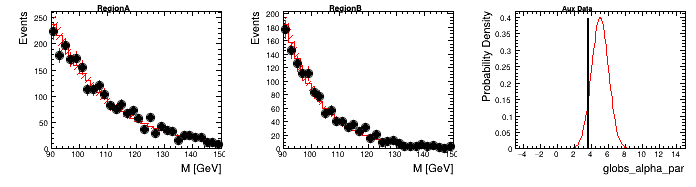

In [6]:
plot(model,obsData)

Discussion: What are we seeing?

<span style="color:blue">*We are seeing the mass distibution for two difference categories and one parameter of the model*</span>

<span style="color:orange">**Task: Access the variables of the model and understand what they represent. Which are observables, global observables, and parameters? Change the parameter values and replot the model to understand their effect. Generate some toy datasets and visualize them too, and try running a fit...**</span>

In [7]:
vars = model.getVariables()
vars.Print("v")
observables = vars.selectByAttrib("obs", True)
global_obs = vars.selectByAttrib("global", True)
floating = vars.selectByAttrib("Constant", False)
constant = vars.selectByAttrib("Constant", True)

  1) 0x1eef7850 RooRealVar::               1 = 1 C  L(-1e+30 - 1e+30)  "1"
  2) 0x1dbca560 RooRealVar::       alpha_par = 5 +/- 1  L(0 - 100)  "alpha_par"
  3) 0x1daf1360 RooCategory::      channelCat = RegionA(idx = 0)
  "channelCat"
  4) 0x1c4ae9e0 RooRealVar:: globs_alpha_par = 14.9 C  L(-5 - 15)  "globs_alpha_par"
  5) 0x1ec93750 RooRealVar::           m_obs = 149  L(90 - 150) B(30)  "M [GeV]"
  6) 0x1bfa5220 RooRealVar::              mu = 0  L(0 - 100)  "mu"
  7) 0x1c10f040 RooRealVar::        sig_mass = 110 C  L(-1e+30 - 1e+30)  "sig_mass"
  8) 0x1c2837b0 RooRealVar::       sig_width = 2 C  L(-1e+30 - 1e+30)  "sig_width"


In [8]:
print("All vars:", [v.GetName() for v in vars])
print("Obs:", [v.GetName() for v in observables])
print("Globals:", [v.GetName() for v in global_obs])
print("Floating:", [v.GetName() for v in floating])
print("Constant:", [v.GetName() for v in constant])

All vars: ['1', 'alpha_par', 'channelCat', 'globs_alpha_par', 'm_obs', 'mu', 'sig_mass', 'sig_width']
Obs: ['channelCat', 'globs_alpha_par', 'm_obs']
Globals: ['globs_alpha_par']
Floating: ['alpha_par', 'channelCat', 'm_obs', 'mu']
Constant: ['1', 'globs_alpha_par', 'sig_mass', 'sig_width']


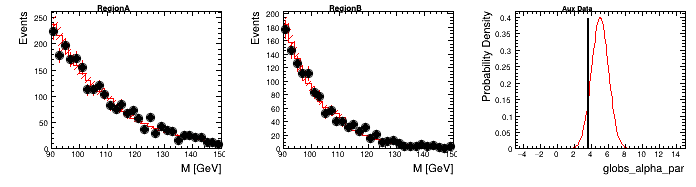

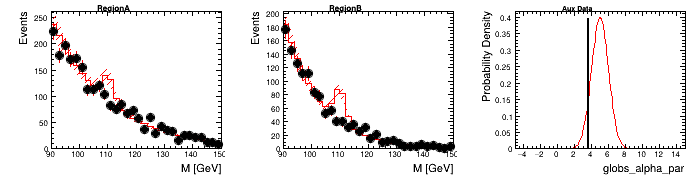

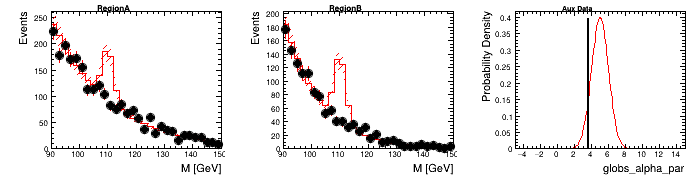

In [9]:
myvars = model.getVariables()

sig_mass = myvars.find("sig_mass")
mu = myvars.find("mu")
mu.setVal(1)
plot(model, obsData)
mu.setVal(5)
plot(model, obsData)
mu.setVal(10)
plot(model, obsData)

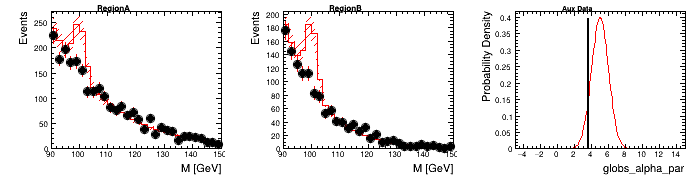

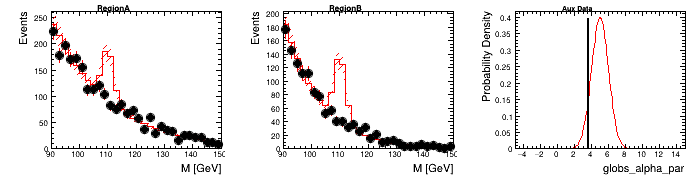

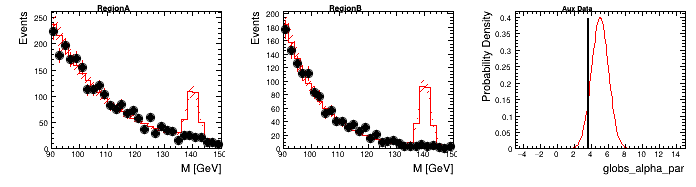

In [10]:
mu = myvars.find("mu")
sig_mass.setVal(100)
plot(model, obsData)
sig_mass.setVal(110)
plot(model, obsData)
sig_mass.setVal(140)
plot(model, obsData)

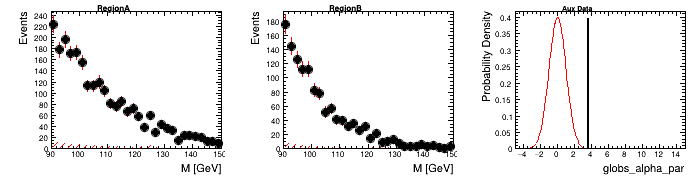

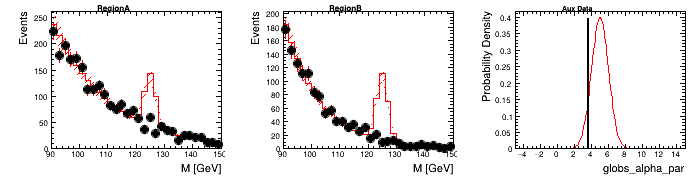

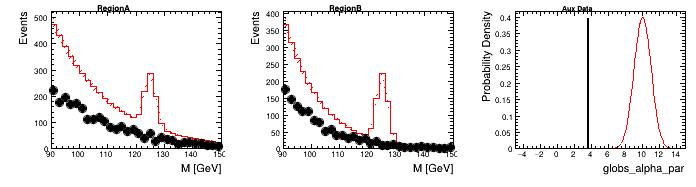

In [11]:
globs_alpha_par= myvars.find("alpha_par")
sig_mass.setVal(125)
globs_alpha_par.setVal(0)
plot(model, obsData)
globs_alpha_par.setVal(5)
plot(model, obsData)
globs_alpha_par.setVal(10)
plot(model, obsData)

<span style="color:blue">The signal_mass is the mass of the searched paticle in the model, The signal strange how much signal events are produced, and the parameter alpha control de background </span>

<span style="color:orange">**Task: Assign the variables representing signal mass and signal strength to the python variables below...**</span>

In [12]:
sig_mass.setVal(125)
mu.setVal(0)
globs_alpha_par.setVal(5)
mass_var = sig_mass
mu_var = mu

## Hypothesis Testing: Exclusions and Discovery

Exclusions and Discovery plots are just a way of presenting the results of a collection of Hypothesis Tests. A Hypothesis Test is really the process of calculating a p-value and seeing whether its less than or greater than a  critical value (0.05 in the case of 95% CL). The procedure for making these plots is as follows:

  1. Define a `Hypothesis Space`, which involves deciding which parameters of the BSM model we want to scan over.
      (elsewhere people call this a *parameter grid*):
  2. Choose a `Test Statistic` to perform hypothesis tests with, the normal choice is:
      * Exclusions: A one-sided *capped-above* Profile Likelihood Ratio Test Statistic ($q_\mu$ or $\tilde{q}_\mu$)
      * Discovery: A one-sided *capped-below* Profile Likelihood Ratio Test Statistic $q_0$
  3. Choose a definition of `P Value` to use, there are three types:
      * null p-value: The p-value under the null hypothesis (the hypothesis being tested)
         * In exclusion tests the null hypothsesis is a particular s+b hypothesis, and null p-value is sometimes then called the CLs+b p-value.
         * In discovery tests the null hypothesis is the bkg-only hypothesis, and the null p-value is sometimes called the $p_0$ p-value.
      * alt p-value: The p-value under an alternative hypothesis (only relevant for exclusions), also calld the CLb p-value
      * CLs p-value: The ratio of the above two p-values
  4. Find the contour of `Hypothesis Points` in your `Hypothesis Space` where your chosen p-value equals the critical value (0.05 for a 95% confidence limit). This is usually done by selecting a grid of points in the space and computing the p-value for each (aka doing a hypothesis test), then interpolating between them to give you a contour. 
  5. `Expected` contours can also be computed by throwing toys from the expected hypothesis and computing the median p-value of these toys at each hypothesis point. The contour is drawn as before by interpolating these median p-values across the space. 1 sigma and 2 sigma "bands" can be computed by examining a different p-value than the median one, as we will discuss later.
      * Note that the expected contour is often instead estimated by using the *Asimov Dataset* which corresponds to the expected data under the alternative hypothesis. This is not quite the same as using toys but usually gives a very similar result.

### 1. The Hypothesis Space

Our hypothesis space will span signal mass in the x-axis, and signal strength in the y-axis. We will leave signal width fixed. Note that you don't have to choose signal strength as one of your space axis parameters, SUSY analyses for example often scan over a pair of masses and leave signal strength fixed to 1. 

We'll use a `TGraph` to keep track of which points we are running hypothesis tests for

Info in <TCanvas::MakeDefCanvas>:  created default TCanvas with name c1


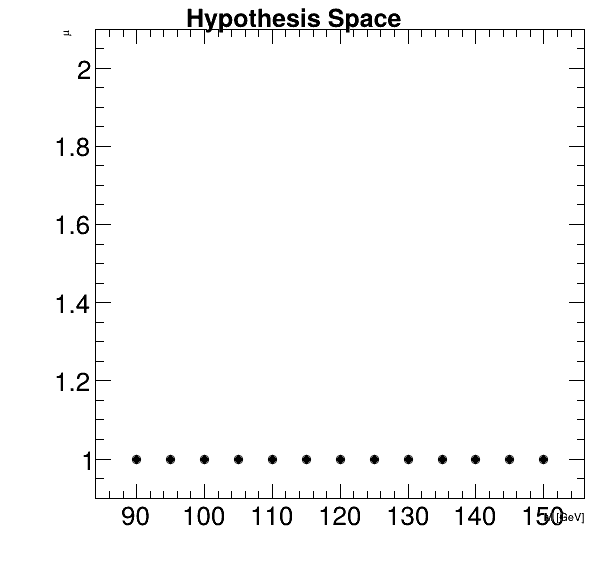

In [13]:
hypoSpace = ROOT.TGraph()
hypoSpace.SetTitle("Hypothesis Space;M [GeV];#mu")

# start with just some points @ mu=1
mass_var.setVal(90.0)
mu_var.setVal(1.0)

while mass_var.getVal()<=150.0:
    hypoSpace.AddPoint(mass_var.getVal(),mu_var.getVal())
    mass_var.setVal(mass_var.getVal()+5.0)

myPlot = ROOT.gROOT.MakeDefCanvas()
hypoSpace.Draw("AP")
myPlot.Draw()

### 2. The Test Statistic 

The test statistics we are using are all based on the *(two-sided) profile likelihood ratio*, $t_\mu$:

$$
t_\mu = -2\text{ln}\left( \frac{L(\mu,\hat{\hat{\theta}})}{L(\hat{\mu},\hat{\theta})}\right)
$$

The test statistic we will use for limits is the *one-sided capped-above profile likelihood ratio* , $q_\mu$:

$$
q_\mu = \begin{cases}
    t_\mu \text{ if $\hat\mu < \mu$,} \\
    0 \text{ if $\hat\mu >= \mu$}.
    \end{cases}
$$

The test statistic we will use discovery is the *one-sided capped-below profile likelihood ratio*, $q_0$:

$$
q_0 = \begin{cases}
    t_{\mu=0} \text{ if $\hat\mu > 0$,} \\
    0 \text{ if $\hat\mu <= 0$}.
    \end{cases}
$$

Question: Which test statistic are we going to use for our exclusion limits?

Question: Are the one-sided test statistics continuous or do they have a jump in them? What happens when $\hat{\mu} = \mu$ ? 

<span style="color:orange">**Task: Implement a function that can calculate any of these profile likelihood test statistics ...**</span>

In [14]:
def pll(mu_test, data, oneSided=False, cappedAbove=True):
    mu_var.setConstant(False) # is mu floating or constant in unconditional fit
    ufit = fit(model,data)
    if ufit.status()!=0:
        print("Unconditional fit failed",ufit.status())
        return None
    if oneSided:
        # uncomment the correct pair of lines
        #1. 
        # if cappedAbove and ufit.floatParsFinal().find(mu_var.GetName()).getVal() <= mu_test : return 0.0
        # if not cappedAbove and ufit.floatParsFinal().find(mu_var.GetName()).getVal() >= mu_test: return 0.0
        #2. 
        # if cappedAbove and ufit.constPars().find(mu_var.GetName()).getVal() >= mu_test : return 0.0
        # if not cappedAbove and ufit.constPars().find(mu_var.GetName()).getVal() <= mu_test: return 0.0
        #3. 
        if cappedAbove and ufit.floatParsFinal().find(mu_var.GetName()).getVal() >= mu_test : return 0.0
        if not cappedAbove and ufit.floatParsFinal().find(mu_var.GetName()).getVal() <= mu_test: return 0.0
    mu_var.setVal(mu_test);mu_var.setConstant(True) # what to set here for the conditional fit (numerator)
    cfit = fit(model,data)
    if cfit.status()!=0:
        print("Conditional fit failed",cfit.status())
        return None
    return 2.0 * (cfit.minNll() - ufit.minNll())

Now we use your function to evaluate the test statistic with the observed data at $\mu=1$ at different values of signal mass.

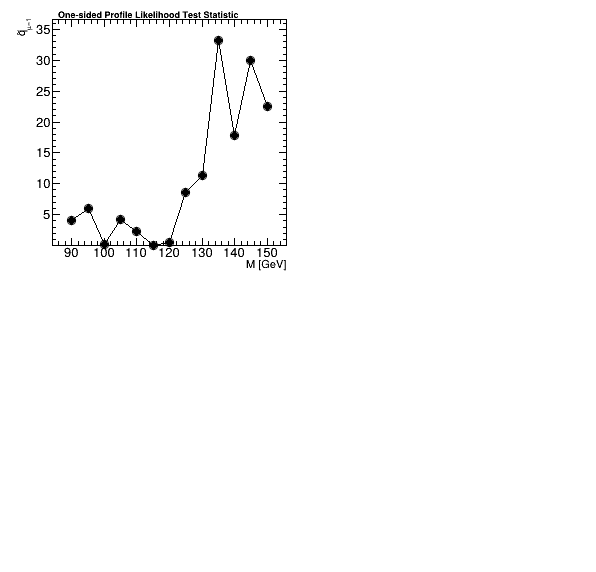

In [15]:
c = ROOT.TCanvas()
c.DivideSquare(4)

obs_plls = ROOT.TGraph()
obs_plls.SetTitle("One-sided Profile Likelihood Test Statistic;M [GeV];#tilde{q}_{#mu=1}")

for i in range(hypoSpace.GetN()):
    mass_var.setVal(hypoSpace.GetPointX(i))
    obs_pll = pll(1.0, obsData, True, True)
    obs_plls.AddPoint(mass_var.getVal(),obs_pll)
    
c.SetSelectedPad( c.GetPad(1).cd() )
obs_plls.DrawClone("ALP")
c.Draw()

Questions:
   * What is the meaning of this test statistic value? What does a small or big value mean?
   * Why this test statistic for hypothesis testing?

### 3. The P-Value

Now, this is the computationally difficult bit. We need to know the p-value of our observed test statistic values. For the CLs+b p-value this is the fraction of toys generated under the null hypothesis that had a test statistic value greater than the one we observed. The CLb is similar but with toys generated under the alternative hypothesis. 

<span style="color:orange">**Task: Implement a function that can generate the test statistic distribution from toys for a single hypothesis point and use it to estimate the p-value for a single point ...**</span>

In [16]:
def pvalue(nToys, mu_true, obs_ts):
    mu_test = mu_var.getVal()
    hist = ROOT.TH1D("toys","",100,0,2.5*obs_ts)
    hist.SetDirectory(0)
    
    # to generate toys under the "true" hypothesis we need the fitResult of the obs data to that specific hypothesis
    
    # uncomment the correct line
    #1.
    #mu_var.setVal(mu_test);mu_var.setConstant()
    #2.
    #mu_var.setVal(mu_true);mu_var.setConstant(False)
    #3.
    mu_var.setVal(mu_true);mu_var.setConstant()
    true_fit = fit(model,obsData)
        
    nUp = 0
    for i in tqdm.tqdm(range(nToys)):
        mu_var.setVal(mu_test) # q: why might it be good to set mu_var back to mu_test before each pll evaluation?
        toy_ts = pll(mu_test, generate(model,true_fit), True, True)
        if toy_ts is None:
            continue
        nUp += (toy_ts >= obs_ts)
        hist.Fill(toy_ts)
    
    # convert hist into a PDF by normalizing and dividing by bin width
    hist.Scale(1./(nToys*hist.GetBinWidth(1)))
    
    # leave mu at its original value
    mu_var.setVal(mu_test)
    
    hist.SetTitle("M = {} GeV, #mu' = {} : pval = {};q_{{#mu={}}}".format(mass_var.getVal(),mu_true,nUp/nToys,mu_test))
    
    return nUp/nToys , hist 

mu_var.setVal(hypoSpace.GetPointY(5))
mass_var.setVal(hypoSpace.GetPointX(5))
pval_clsb, nullHist = pvalue(2000,1,obs_plls.GetPointY(5))
pval_clb, altHist = pvalue(1000,0,obs_plls.GetPointY(5))


 25%|███████████████████████████████████████████▍                                                                                                                                 | 251/1000 [00:05<00:17, 42.74it/s]

Unconditional fit failed -1


 68%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▊                                                        | 675/1000 [00:14<00:06, 48.20it/s]

Unconditional fit failed -1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:21<00:00, 46.76it/s]


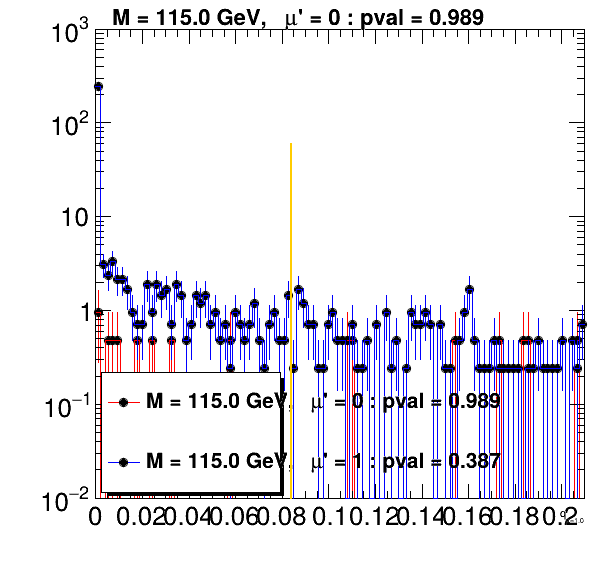

In [17]:
altHist.GetYaxis().SetRangeUser(0.01, 1000)
nullHist.SetLineColor(ROOT.kBlue);altHist.SetLineColor(ROOT.kRed)
myPlot.cd(); myPlot.SetLogy()
altHist.DrawClone("histe")
nullHist.DrawClone("histe same")
legend = myPlot.BuildLegend()
legend.SetTextSize(0.04)
l = ROOT.TLine();l.SetLineColor(ROOT.kOrange);l.SetLineWidth(2);l.DrawLine(obs_plls.GetPointY(5),0,obs_plls.GetPointY(5),60) # obs ts value

# 4. Force the canvas to update and render the changes
myPlot.Draw()


Questions:

  * Why do the alt hypothesis toys take longer to run than the null hypothesis toys?
 
  <span style="color:blue"> Generate just background events is simple than generate signal + background </span>
  * How would we extract the expected p-value from this plot?

<span style="color:blue"> Take the integral from the observed value to infinity </span>

  * Should p-values have an uncertainty?

<span style="color:blue"> Yes, they do. Comes from a binomial distribution: \begin{equation}
\sigma_p = \sqrt{\frac{p(1-p)}{N_{toys}}}
\end{equation}  </span>

    
  * How many toys?
    
<span style="color:blue"> Depends on the value of p, is p is large, you need less toys. If p is really small you may need even millions  </span>

### A shortcut to p-values: Asymptotic formulae



In [18]:
help(asymptotic_pvalue_qmu)

Help on function asymptotic_pvalue_qmu in module __main__:

asymptotic_pvalue_qmu(qmu, mu, mu_prime, sigma_mu, mu_min=-inf, mu_max=inf)
    Returns the asymptotic p-value of qmu test statistic
    qmu : the one-sided-positive test statistic value
    mu : the null hypothesis mu value
    mu_prime : the true hypothesis mu value ( = mu for null hypothesis )
    sigma_mu : stdev of mu_hat under the true hypothesis (estimate as |mu - mu_prime|/sqrt(tmu(asimov_mu_prime)))
    mu_min : min value of mu
    mu_max : max value of mu



<span style="color:orange">**Task: Write a function to fill a graph with the PDF of the asymptotic p-value. Use it to explore the shape of the function for different values of $\sigma_{\hat{\mu}}$ and $\mu$ ...**</span>

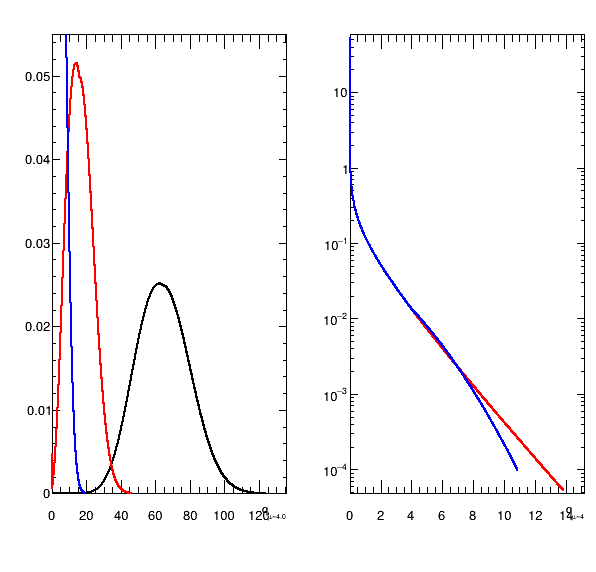

In [19]:
def asymptotic_graph(mu_test, mu_prime, sigma_mu):
    out = ROOT.TGraph(); out.SetLineWidth(2); out.SetTitle(";q_{{#mu={}}}".format(mu_test))
    pval = 1.;qmu = 0; step = 0.01
    while pval > 0.0001:
        # which line is right?
        next_pval = asymptotic_pvalue_qmu(qmu+step, mu_test, mu_prime, sigma_mu, 0)
        #next_pval = asymptotic_pvalue_qmu(qmu, mu_test, mu_prime, sigma_mu)
        #next_pval = asymptotic_pvalue_qmu(step, mu_test, mu_prime, sigma_mu, 0)
        out.AddPoint(qmu+0.5*step, (pval-next_pval)/step)
        pval = next_pval
        qmu += step
    return out
    
myPlot.cd()
myPlot.Clear()
myPlot.Divide(2,1)
myPlot.cd(1)
graph_clb = asymptotic_graph(4.0, 0.0, 0.5)
graph_clb.SetMaximum(0.055) 
graph_clb.Draw("AL")
n_puntos = graph_clb.GetN()
asymptotic_graph(4,0,1).DrawClone("L").SetLineColor(ROOT.kRed)
asymptotic_graph(4,0,2).DrawClone("L").SetLineColor(ROOT.kBlue)
myPlot.cd(2).SetLogy()
asymptotic_graph(4,4,0.5).DrawClone("AL")
asymptotic_graph(4,4,1).DrawClone("L").SetLineColor(ROOT.kRed)
asymptotic_graph(4,4,2).DrawClone("L").SetLineColor(ROOT.kBlue)
myPlot.Draw()


Questions:
  * How does the asymptotic distribution depend on $\sigma_{\hat{\mu}}$ parameter?

    <span style="color:blue"> if the uncertanty increases the distribuion shifts to smaller values of $q_\mu$, this means that is harder to reject a theory. when mu_test=mu_prime the result almost do not depend on sigma  </span>
    
  * What happens when plotting the null hypothesis distribution for $\mu=0$? Why?


    <span style="color:blue"> All the events will be acomulated at $q_\mu = 0$  </span>
    

N points = 1
point 0: x = 0.005000, y = 1.000000e+02


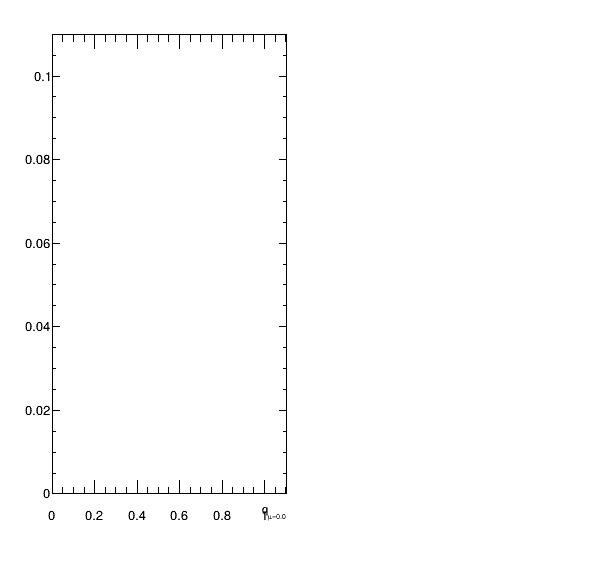

In [20]:
myPlot.cd()
myPlot.Clear()
myPlot.Divide(2,1)
myPlot.cd(1)
graph_clb = asymptotic_graph(0.0, 0.0, 0.5)
graph_clb.SetMaximum(0.055) 
graph_clb.Draw("AL")
n_puntos = graph_clb.GetN()
asymptotic_graph(0,0,1).DrawClone("L").SetLineColor(ROOT.kRed)
asymptotic_graph(0,0,2).DrawClone("L").SetLineColor(ROOT.kBlue)
myPlot.Draw()
print("N points =", graph_clb.GetN())

for i in range(graph_clb.GetN()):
    x = graph_clb.GetPointX(i)
    y = graph_clb.GetPointY(i)
    print(f"point {i}: x = {x:.6f}, y = {y:.6e}")

To use the asymptotic formulae we will need to estimate $\sigma_{\hat{\mu}}$, which we can do with the asimov dataset (the expected dataset) and using the formula:
$$
\sigma_{\hat{\mu}}\approx\frac{\mu - \mu'}{\sqrt{t_\mu( D_{exp}(\mu') )}}
$$

where $\mu$ is the hypothesis being tested, $\mu'$ is the 'true' hypothesis, $t_\mu(...)$ is the regular (two-sided) profile likelihood ratio, and $D_{exp}(\mu')$ is the asimov dataset under the $\mu'$ hypothesis.

Task: Write code to estimate $\sigma_{\hat{\mu}}$ for the hypothesis points in our hypothesis space:

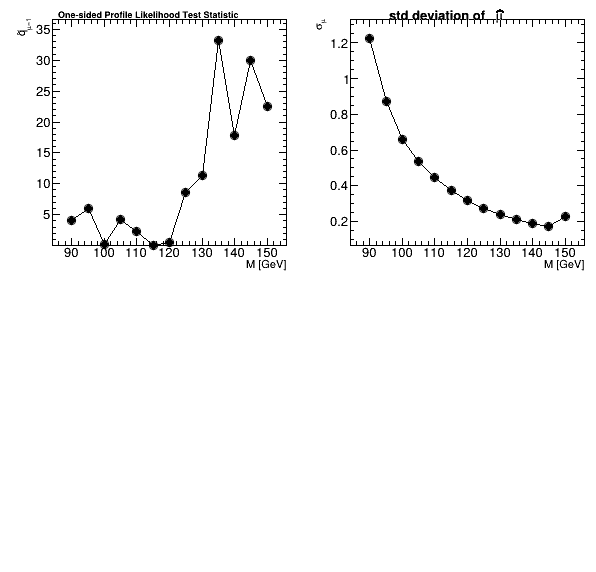

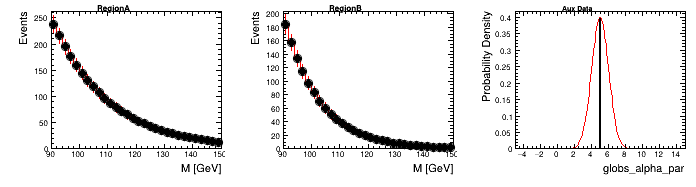

In [21]:
sigma_mus = ROOT.TGraph()
sigma_mus.SetTitle("std deviation of #hat{#mu};M [GeV];#sigma_{#mu}")

# Generate the asimov (expected) dataset for the mu=0 hypothesis
# need to define the appropriate 'fit result' representing that hypothesis....
# can do this here because cfit for all signals will be same for mu=0
mu_alt = 0
mu_var.setVal(mu_alt); mu_var.setConstant(True)
cfit = fit(model, obsData)
asimovData = generate(model,cfit,True) # the 'True' means generate expected (asimov) data - we could plot it too....
plot(model, asimovData)
import math
for i in range(hypoSpace.GetN()):
    mass_var.setVal(hypoSpace.GetPointX(i))
    mu_test = hypoSpace.GetPointY(i)
    asimov_pll = pll(mu_test, asimovData, False, True)
    if not asimov_pll: continue
    sigma_mu = (mu_test-mu_alt)/math.sqrt( asimov_pll )
    sigma_mus.AddPoint(hypoSpace.GetPointX(i),sigma_mu)
    
c.cd(2)
sigma_mus.Draw("ALP")
c.Draw()

Discussion: Interpretation of $\sigma_{\hat{\mu}}$ distribution...
<span style="color:blue"> The model is more sensite for bigger values of the mass </span>

Question: Cause of uptick in the $\sigma_{\hat{\mu}}$ at the end of the mass observable space?
    <span style="color:blue"> Because there is a limit on the mass, so some events are rejected are there is less information, therefore, less presion  </span>


Now that we have computed $\sigma_{\hat{\mu}}$ values, plot the asymptotic distribution on top of the toy distribution you generated earlier for a single hypothesis point to assess if for that particular point if we are in the "asymptotic regime" ...

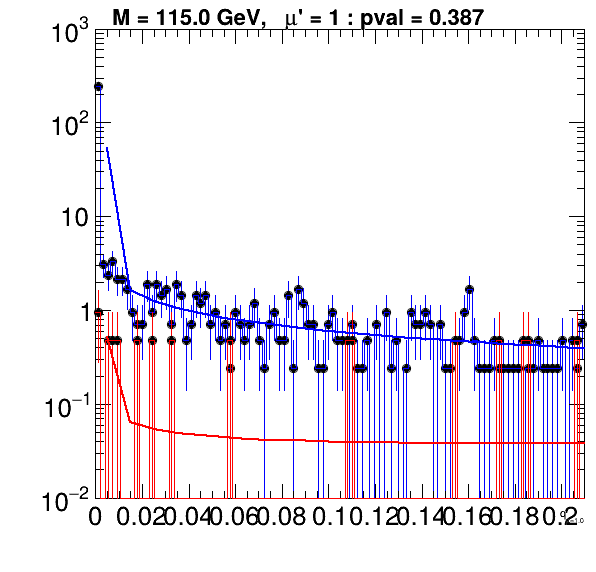

In [22]:
nullGr = asymptotic_graph(1,1,sigma_mus.GetPointY(5))
altGr = asymptotic_graph(1,0,sigma_mus.GetPointY(5))
nullGr.SetLineColor(nullHist.GetLineColor())
altGr.SetLineColor(altHist.GetLineColor())


myPlot.cd()
nullHist.SetMinimum(0.01)
nullHist.SetMaximum(1000)
nullHist.DrawClone("histe");altHist.DrawClone("histe same")
nullGr.Draw("L"); altGr.Draw("L")
myPlot.Draw()

<span style="color:orange">**Task: Now use the asymptotic formulae function (`asymptotic_pvalue_qmu`) to graph the asymptotic CLs p-value across all the hypothesis points .. hint: you need to use your obs_plls and sigma_mus:**</span>

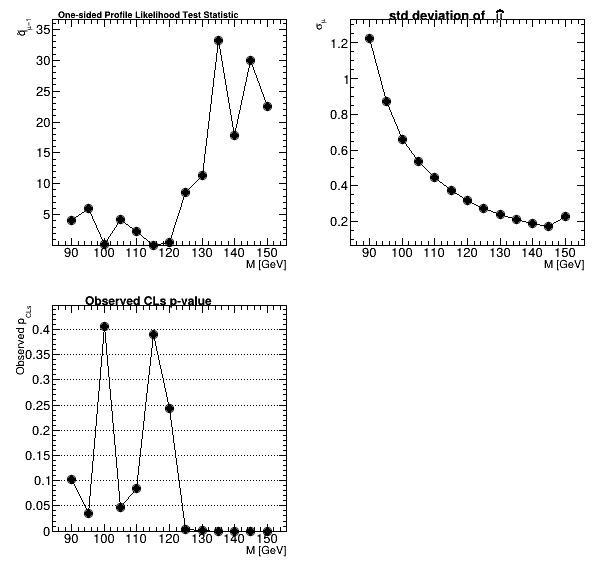

In [23]:
obs_pvals = ROOT.TGraph()
obs_pvals.SetTitle("Observed CLs p-value;M [GeV];Observed p_{CLs}")
# help(asymptotic_pvalue_qmu)
for i in range(hypoSpace.GetN()):
    qmu = obs_plls.GetPointY(i)
    mu = hypoSpace.GetPointY(i)
    sigma_mu = sigma_mus.GetPointY(i)

    psb = asymptotic_pvalue_qmu(qmu, mu, mu, sigma_mu, 0)
    pb  = asymptotic_pvalue_qmu(qmu, mu, 0,  sigma_mu, 0)

    obs_pvals.AddPoint(hypoSpace.GetPointX(i), psb / pb)
    
c.cd(3)
obs_pvals.Draw("ALP")
ROOT.gPad.SetGridy()
c.Draw()

## 4. Finding the P-Value Contours

Now that we have a quick way to estimate p-values, our objective is to find the contour of hypothesis points in a full hypothesis where the p-value equals the critical value. 

Question: For a 95% CL limit, what is the critical value?

<span style="color:orange">**Task: Define a full 2D hypothesis space, scanning mu values from 0.1 to 4.9 in steps of 0.2, and mass values from 90-150 in steps of 5 GeV:**</span>

In [24]:
fullHypoSpace = ROOT.TGraph()
fullHypoSpace.SetTitle("Full Hypothesis Space;M [GeV];#mu")
mu_var.setVal(0.1)

while mu_var.getVal() <= 4.9:
    mass_var.setVal(90.0)
    while mass_var.getVal() <= 150.0:
        fullHypoSpace.AddPoint(mass_var.getVal(), mu_var.getVal())
        mass_var.setVal(mass_var.getVal() + 5.0)
    mu_var.setVal(mu_var.getVal() + 0.2)

<span style="color:orange">**Task: Use the asymptotic formulae function to compute the p-values across the full hypothesis space:**</span>

In [25]:
# now get p-value at every point in hypospace and plot contour where equals 0.05
full_obs_pvals = ROOT.TGraph2D(); full_obs_pvals.SetTitle("Observed CLs p-values;M [GeV];#mu")
full_sigma_mu = ROOT.TGraph2D();  # use this to save all the sigma_mu values

for i in tqdm.tqdm(range(fullHypoSpace.GetN())):
    mass_var.setVal(fullHypoSpace.GetPointX(i))
    asimov_pll = pll(fullHypoSpace.GetPointY(i), asimovData, False, True)
    if not asimov_pll:
        print("skipping", fullHypoSpace.GetPointX(i), fullHypoSpace.GetPointY(i))
        full_sigma_mu.AddPoint(fullHypoSpace.GetPointX(i), fullHypoSpace.GetPointY(i), 0)
        continue

    sigma_mu = (fullHypoSpace.GetPointY(i) - mu_alt) / math.sqrt(asimov_pll)
    full_sigma_mu.AddPoint(fullHypoSpace.GetPointX(i), fullHypoSpace.GetPointY(i), sigma_mu)

    obs_pll = pll(fullHypoSpace.GetPointY(i), obsData, True, True)

    p_null = asymptotic_pvalue_qmu(obs_pll, fullHypoSpace.GetPointY(i), fullHypoSpace.GetPointY(i), sigma_mu, 0)
    p_alt  = asymptotic_pvalue_qmu(obs_pll, fullHypoSpace.GetPointY(i), 0, sigma_mu, 0)
    full_obs_pvals.AddPoint(
        fullHypoSpace.GetPointX(i),
        fullHypoSpace.GetPointY(i),
        p_null / p_alt if p_alt > 0 else (1 if p_null == p_alt else float('nan'))
    )

 16%|████████████████████████████▌                                                                                                                                                  | 51/312 [00:00<00:03, 68.88it/s]

Unconditional fit failed -1
skipping 100.0 0.7


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:05<00:00, 59.59it/s]


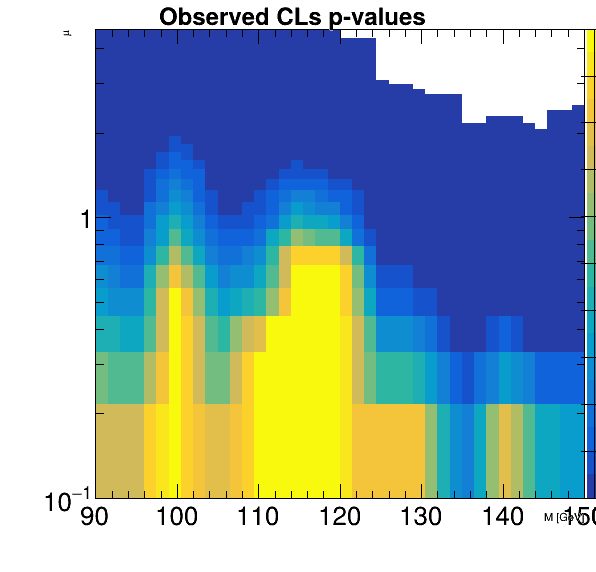

In [26]:
# visualize our p-value graph
myPlot.cd()
full_obs_pvals.Draw("COLZ"); # can also do COLZ draw style
myPlot.Draw()

These p-value 2D graphs are used to extract the 95% CLs limits. This is done by finding the contours where the p-value equals 0.05.

Question: What piece of information would we need in order to compute an expected limit contour?

<span style="color:orange">**Task: Use the `asymptotic_expected_qmu` function provided in this lab to compute the p-value graphs for $-2\sigma$ to $2\sigma$:**</span>

In [27]:
help(asymptotic_expected_qmu)

Help on function asymptotic_expected_qmu in module __main__:

asymptotic_expected_qmu(pvalue, mu, mu_prime, sigma_mu, mu_min=-inf, mu_max=inf)
    Returns the qmu test statistic value corresponding to a given given p-value:
      pvalue : The pvalue that the returning test statistic would have under the true hypothesis (mu_prime)
      mu : The null hypothesis value of mu
      mu_prime : the true hypothesis mu value ( = mu for null hypothesis )
      sigma_mu : stdev of mu_hat under the true hypothesis (estimate as |mu - mu_prime|/sqrt(tmu(asimov_mu_prime))). Dependence on this parameter disappears for mu=mu_prime=0.
      mu_min : min value of mu
      mu_max : max value of mu



In [28]:
# we will keep the collection of expected p-values in a dictionary of graphs
# a defaultdict is just a way to have a dictionary that will automatically create a new TGraph2D for us
# when we access a new key in the dictionary
from collections import defaultdict
full_exp_pvals = defaultdict(ROOT.TGraph2D)

for i in tqdm.tqdm(range(fullHypoSpace.GetN())):
    mass_var.setVal(fullHypoSpace.GetPointX(i))
    sigma_mu = full_sigma_mu.GetZ()[i] 
    
    def doExpected(nSigma):
        exp_p_true = ROOT.Math.normal_cdf(nSigma)  # the p-value of the nSigma toy under the true (i.e. alt) hypothesis

        # get test statistic value corresponding to this p-value:
        exp_pll = asymptotic_expected_qmu(exp_p_true, fullHypoSpace.GetPointY(i), 0, sigma_mu, 0)

        p_null = asymptotic_pvalue_qmu(exp_pll, fullHypoSpace.GetPointY(i), fullHypoSpace.GetPointY(i), sigma_mu, 0)
        p_alt  = asymptotic_pvalue_qmu(exp_pll, fullHypoSpace.GetPointY(i), 0, sigma_mu, 0)

        full_exp_pvals[nSigma].AddPoint(
            fullHypoSpace.GetPointX(i),
            fullHypoSpace.GetPointY(i),
            p_null / p_alt if p_alt > 0 else (1 if p_null == p_alt else float('nan'))
        )

        if nSigma > 0:
            doExpected(-nSigma)
    
    doExpected(0)
    doExpected(1)
    doExpected(2)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 312/312 [00:00<00:00, 477.92it/s]


The following code block will do the contour finding from your p-value graphs and visualize the results for you.

Discussion point: Interpolating significances rather than p-values 

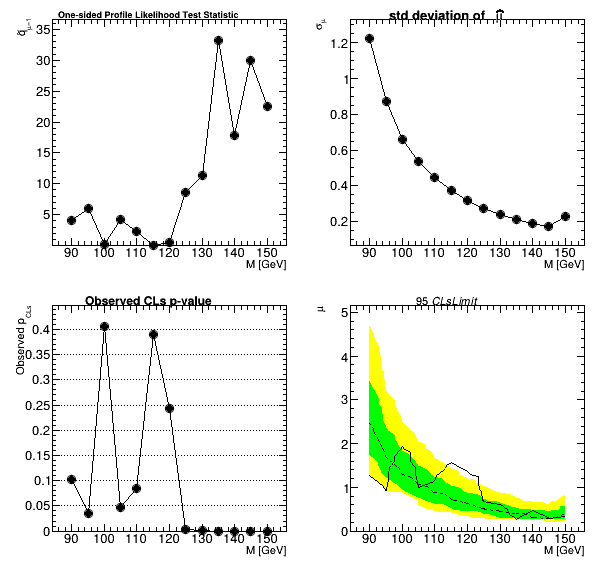

In [29]:
# This code is one way to estimate the pvalue=0.05 contours in your graphs. 
# It will also combine the +/-1sigma and +/-2sigma contours so that they can be visualized as 
# green and yellow 'bands' respectively

c.cd(4);
obs_limit = full_obs_pvals.GetContourList(0.05).At(0)
exp_limit = full_exp_pvals[0].GetContourList(0.05).At(0)
exp2_limit = full_exp_pvals[2].GetContourList(0.05).At(0)
expm2_limit = full_exp_pvals[-2].GetContourList(0.05).At(0)

# combine the two contours so can draw as a 'band'
exp2_limit.Sort();expm2_limit.Sort(ROOT.TGraph.CompareX,False)
l = ROOT.TList(); l.Add(expm2_limit)
exp2_limit.Merge(l)

exp1_limit = full_exp_pvals[1].GetContourList(0.05).At(0)
expm1_limit = full_exp_pvals[-1].GetContourList(0.05).At(0)

# likewise for 1sigma 'band'
exp1_limit.Sort();expm1_limit.Sort(ROOT.TGraph.CompareX,False)
l = ROOT.TList(); l.Add(expm1_limit)
exp1_limit.Merge(l)

exp2_limit.SetFillColor(ROOT.kYellow)
exp1_limit.SetFillColor(ROOT.kGreen)
exp_limit.SetLineStyle(2)
exp2_limit.SetTitle(r"95\% CLs Limit;M [GeV];#mu");
exp2_limit.SetMinimum(0.0)
exp2_limit.Draw("AF")
exp1_limit.Draw("F")
exp_limit.Draw("L")
obs_limit.Draw("L")

c.Draw()

Discussion: It still took a while to get the p-value of every point in the hypothesis space. How could we be even more efficient with our exclusion limit calculation? 

## Discovery Hypothesis Testing

This is a test of the SM (bkg only) hypothesis, using the "one sided capped-below" profile likelihood ratio as a test statistic, $q_0$, and the null hypothesis p-value. 

<span style="color:orange">**Task: Create an appropriate discovery hypothesis space (mass between 90 and 150 in steps of 5):**</span> 

In [30]:
dHypoSpace = ROOT.TGraph()
dHypoSpace.SetTitle("Discovery Hypothesis Space;M [GeV];#mu")
mu_var.setVal(0) # we are always testing the same value of mu in discovery ... which value?
mass_var.setVal(90) # but we will move between different mass points
while mass_var.getVal()<=150:
    dHypoSpace.AddPoint(mass_var.getVal(),mu_var.getVal())
    mass_var.setVal(mass_var.getVal()+5)

The asymptotic formula for the q0 test statistic is coded in the function `asymptotic_pvalue_q0` and there is also the function `asymptotic_expected_q0` for the value of $q_0$ corresponding to a particular p-value.

In [31]:
help(asymptotic_pvalue_q0)
help(asymptotic_expected_q0)

Help on function asymptotic_pvalue_q0 in module __main__:

asymptotic_pvalue_q0(q0, mu, mu_prime, sigma_mu, mu_min=-inf, mu_max=inf)
    q0 : the one-sided-negative test statistic value
    mu : the null hypothesis mu value
    mu_prime : the true hypothesis mu value ( = mu for null hypothesis )
    sigma_mu : stdev of mu_hat under the true hypothesis (estimate as |mu - mu_prime|/sqrt(tmu(asimov_mu_prime))). Dependence on this parameter disappears for mu=mu_prime=0.
    mu_min : min value of mu
    mu_max : max value of mu

Help on function asymptotic_expected_q0 in module __main__:

asymptotic_expected_q0(pvalue, mu, mu_prime, sigma_mu, mu_min=-inf, mu_max=inf)
    Returns the q0 test statistic value corresponding to a given given p-value:
      pvalue : The pvalue that the returning test statistic would have under the true hypothesis (mu_prime)
      mu : The null hypothesis value of mu
      mu_prime : the true hypothesis mu value ( = mu for null hypothesis )
      sigma_mu : stdev 

Note that in discovery tests it appears that the asymptotic p-value distribution doesn't depend on $\sigma_\mu$, so we can just use any value.

<span style="color:orange">**Task: Compute the null hypothesis p-values and the expected null hypothesis p-values assuming a true hypothesis of $\mu=1$:**</span> 

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 40.40it/s]


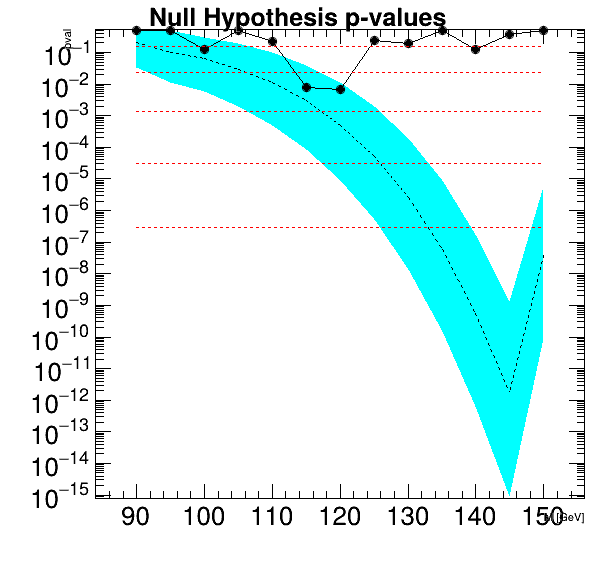

In [32]:
null_pvals = ROOT.TGraph()
null_pvals.SetTitle("Null Hypothesis P-Values;M [GeV];pval")
from collections import defaultdict
exp_pvals = defaultdict(ROOT.TGraph)

for i in tqdm.tqdm(range(dHypoSpace.GetN())):
    mass_var.setVal(dHypoSpace.GetPointX(i))
    
    mu_test = 0
    mu_true = 1  
    mu_var.setVal(mu_true); mu_var.setConstant(True)
    cfit_true = fit(model, obsData) 
    
    asimov_ts = pll(mu_test, generate(model, cfit_true, True), True, False)
    sigma_mu = abs(mu_test - mu_true) / math.sqrt(asimov_ts)
    
    obs_ts_q0 = pll(mu_test, obsData, True, False) 
    

    p_null = asymptotic_pvalue_q0(obs_ts_q0, mu_test, mu_test, sigma_mu, 0)
    null_pvals.AddPoint(dHypoSpace.GetPointX(i), p_null)
    
    def doExpected(nSigma):
        p_asimov_n = ROOT.Math.normal_cdf(nSigma)
        q0_exp = asymptotic_expected_q0(p_asimov_n, mu_test, mu_true, sigma_mu, 0)
        
        p_exp = asymptotic_pvalue_q0(q0_exp, mu_test, mu_test, sigma_mu, 0)
        
        exp_pvals[nSigma].AddPoint(dHypoSpace.GetPointX(i), p_exp)
        if nSigma > 0: doExpected(-nSigma)
        
    doExpected(0); doExpected(1)
        
myPlot.cd().SetLogy()

exp_pvals[-1].Sort(ROOT.TGraph.CompareX,False)
l = ROOT.TList(); l.Add(exp_pvals[-1])
exp_pvals[1].Merge(l)

exp_pvals[1].SetFillColor(ROOT.kCyan)
exp_pvals[1].SetTitle("Null Hypothesis p-values;M [GeV];pval")
exp_pvals[1].Draw("AF")

exp_pvals[0].SetLineStyle(2)
exp_pvals[0].Draw("L")
null_pvals.Draw("LP")
l = ROOT.TLine(); l.SetLineStyle(2); l.SetLineColor(ROOT.kRed)
def drawSigmaLine(nSigma):
    l.DrawLine(dHypoSpace.GetPointX(0),ROOT.Math.normal_cdf_c(nSigma),dHypoSpace.GetPointX(dHypoSpace.GetN()-1),ROOT.Math.normal_cdf_c(nSigma))
for i in range(1,6): drawSigmaLine(i)
myPlot.Draw()

## Measurement

Now that you may have discovered something we proceed to measurements. To get a measurement of a parameter with an assigned error we need to scan the profile likelihood ratio...

<span style="color:orange">**Task: Scan the PLR of the mass parameter...**</span> 

In [33]:
pll_mass = ROOT.TGraph()
pll_mass.SetTitle(";M [GeV];-2ln#Lambda")

mu_var.setConstant(False)
mu_var.setVal(1.0)

mass_var.setConstant(False)
mass_var.setVal(115.0)
mass_var.setRange(90.0, 150.0)

ufit = fit(model, obsData)
ufit.Print()



  RooFitResult: minimized FCN value: -7789.14, estimated distance to minimum: 1.26561e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
             alpha_par    4.9373e+00 +/-  8.54e-02
                    mu    1.1101e+00 +/-  3.74e-01
              sig_mass    1.1753e+02 +/-  9.83e-01



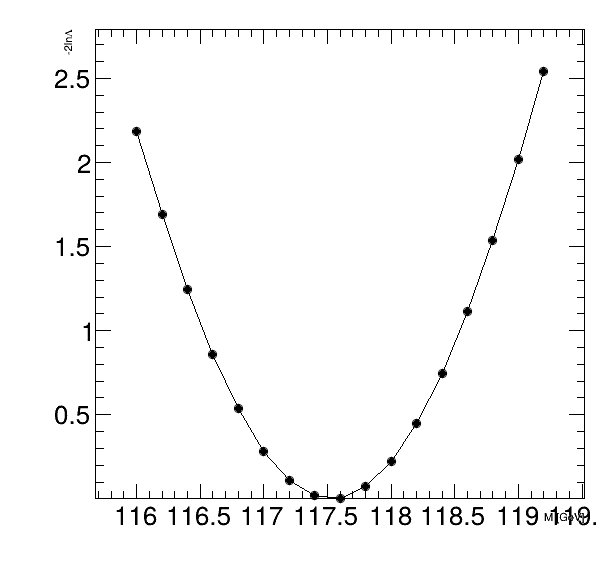

In [34]:

mass_var.setConstant(True); mass_var.setVal(90)
while mass_var.getVal()<150:
    fr = fit(model,obsData)
    # pll = ... formula involves ufit and fr (the conditional fit) ...
    v_pll = 2.0 * (fr.minNll() - ufit.minNll())
    if v_pll < 3:
        pll_mass.AddPoint(mass_var.getVal(),v_pll)
    mass_var.setVal(mass_var.getVal()+(0.2 if v_pll<3 else 1))

myPlot.cd()
ROOT.gPad.SetLogy(False)
pll_mass.Draw("ALP")
ROOT.gPad.Draw()

<span style="color:orange">**Task: Compare and contrast the error from the hessian (in the unconditional fit) to the *minos error*...**</span> 

In [35]:
down = None
up = None

x = pll_mass.GetPointX(0) # start at left-hand edge of pll_mass graph
# scan across the mass finding where the graph becomes equal to 1 ...
# Note: can use graph.Eval(x) to interpolate between points
while up is None:
    if not down and pll_mass.Eval(x)<1: down = x
    if down and pll_mass.Eval(x)>1: up = x
    x += 0.01
        
ufit.Print()

up -= ufit.floatParsFinal().find("sig_mass").getVal()
down -= ufit.floatParsFinal().find("sig_mass").getVal()

print("up=",up,"down=",down)

up= 1.0106863941772417 down= -0.9993136058237866

  RooFitResult: minimized FCN value: -7789.14, estimated distance to minimum: 1.26561e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
             alpha_par    4.9373e+00 +/-  8.54e-02
                    mu    1.1101e+00 +/-  3.74e-01
              sig_mass    1.1753e+02 +/-  9.83e-01



In [36]:
# just do the "post-fit" impact here
def impact(ufit,poiName,npName):
    np_nom = ufit.floatParsFinal().find(npName).getVal()
    np_err = ufit.floatParsFinal().find(npName).getError()
    
    np = model.getVariables().find(npName)
    
    # ensure all parameters of the ufit are floating
    model.getVariables().selectCommon(ufit.floatParsFinal()).setAttribAll("Constant",False)
    
    # run fit where NP is moved to nom+err value and held const, and likewise at nom-err
    np.setConstant()
    np.setVal(np_nom + np_err)
    upfit = fit(model,obsData)
    np.setVal(np_nom - np_err) # COMPLETE THIS LINE
    downfit = fit(model,obsData)
    
    poi_nom = ufit.floatParsFinal().find(poiName).getVal()
    
    return (upfit.floatParsFinal().find(poiName).getVal() - poi_nom) , (downfit.floatParsFinal().find(poiName).getVal() - poi_nom)

print("sig_mass:",impact(ufit,"mu","sig_mass"))
print("alpha_par:",impact(ufit,"mu","alpha_par"))
print("mu:",impact(ufit,"sig_mass","mu"))

sig_mass: (-0.087018130174076, -0.008535120208445157)
alpha_par: (-0.1020381220295461, 0.11106578664327937)
mu: (-0.11375376260146197, 0.1337644858631819)


In [37]:
print("ufit status =", ufit.status())
ufit.Print("v")

ufit status = 0

  RooFitResult: minimized FCN value: -7789.14, estimated distance to minimum: 1.26561e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 

    Constant Parameter    Value     
  --------------------  ------------
                     1    1.0000e+00
       globs_alpha_par    3.5954e+00
             sig_width    2.0000e+00

    Floating Parameter  InitialValue    FinalValue +/-  Error     GblCorr.
  --------------------  ------------  --------------------------  --------
             alpha_par    5.0124e+00    4.9373e+00 +/-  8.54e-02  <none>
                    mu    1.0000e+00    1.1101e+00 +/-  3.74e-01  <none>
              sig_mass    1.1500e+02    1.1753e+02 +/-  9.83e-01  <none>



Finally, lets compute the "impact" of one parameter on another.

<span style="color:orange">**Task: Complete the function below that computes the impact of one parameter with another...**</span> 

Question: How is impact related to covariance?
 ans: The stronger the covariance, the stronger the impact (contrast (1,0) in the covmatrix (alpha impact) bigger than (1,2) (mass impact). Note both covariances negative, reflected in negative impact from positive shift, but covariance unable to capture the 'same side impact' feature of sig_mass which we can understand in terms of the shifting signal peak pushing down the fitted signal strength. 
 

In [38]:
ufit.covarianceMatrix().Print()


3x3 matrix is as follows

     |      0    |      1    |      2    |
--------------------------------------------
   0 |   0.007301   -0.009369    0.003202 
   1 |  -0.009369      0.1397    -0.04775 
   2 |   0.003202    -0.04775      0.9658 



In [39]:
ufit.Print()


  RooFitResult: minimized FCN value: -7789.14, estimated distance to minimum: 1.26561e-06
                covariance matrix quality: Full, accurate covariance matrix
                Status : MINIMIZE=0 

    Floating Parameter    FinalValue +/-  Error   
  --------------------  --------------------------
             alpha_par    4.9373e+00 +/-  8.54e-02
                    mu    1.1101e+00 +/-  3.74e-01
              sig_mass    1.1753e+02 +/-  9.83e-01



### What was the real mass of the particle?

Run `whatIsTheAnswer(day,month)` to find out what was the actual BSM signal mass in your case ... 

In [40]:
whatIsTheAnswer(27,10)

115.67855010391213